In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.image as mpimg
import os

df = pd.read_csv('dataset/car parts.csv')
df.head()

,class index,filepaths,labels,data set
0,0,train/AIR COMPRESSOR/001.jpg,AIR COMPRESSOR,train
1,0,train/AIR COMPRESSOR/002.jpg,AIR COMPRESSOR,train
2,0,train/AIR COMPRESSOR/003.jpg,AIR COMPRESSOR,train
3,0,train/AIR COMPRESSOR/004.jpg,AIR COMPRESSOR,train
4,0,train/AIR COMPRESSOR/005.jpg,AIR COMPRESSOR,train


In [2]:
# df.isna().sum()
# df.info()
0 == df.duplicated().sum()

np.True_

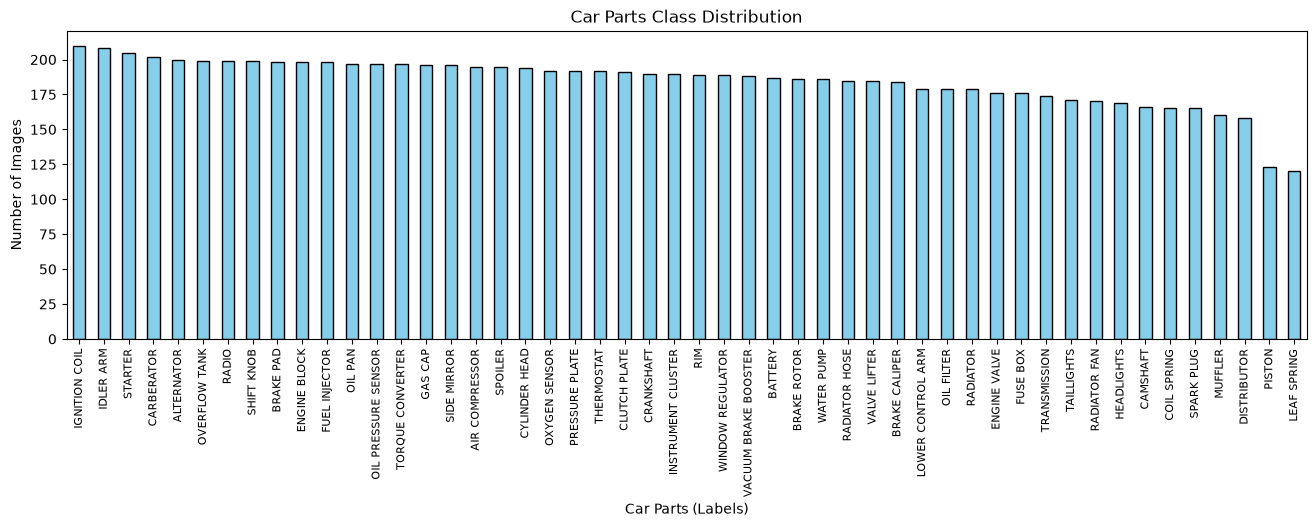

In [3]:
class_count = df['labels'].value_counts()

plt.figure(figsize=(16,4))
class_count.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Car Parts Class Distribution')
plt.xlabel('Car Parts (Labels)')
plt.ylabel('Number of Images')

plt.xticks(rotation=90, fontsize=8)

plt.show()

In [4]:
# Convert counts to a numpy array for mathematical operations
counts = class_count.values

# 1. Imbalance Ratio (IR)
max_class = counts.max()
min_class = counts.min()
imbalance_ratio = max_class / min_class
print(f"Imbalance Ratio (Max/Min): {imbalance_ratio:.2f}")

# 2. Coefficient of Variation (CV)
std_dev = np.std(counts)
mean_val = np.mean(counts)
cv = std_dev / mean_val
print(f"Coefficient of Variation: {cv:.4f} ({cv * 100:.2f}%)")

# 3. Normalized Shannon Entropy (Evenness)
# Calculate proportions
proportions = counts / counts.sum()

# Calculate Shannon Entropy
entropy = -np.sum(proportions * np.log(proportions))

# Calculate Maximum possible entropy (perfect balance)
k = len(counts) # Number of classes 
max_entropy = np.log(k)

# Calculate Normalized Entropy
normalized_entropy = entropy / max_entropy
print(f"Normalized Shannon Entropy: {normalized_entropy:.4f}")

Imbalance Ratio (Max/Min): 1.75
Coefficient of Variation: 0.0970 (9.70%)
Normalized Shannon Entropy: 0.9987


Based on the mathematical evaluation, the dataset exhibits a highly balanced distribution across all 50 car part classes. The imbalance ratio of 1.75 shows that the most frequent class is only slightly larger than the least frequent one, remaining well within acceptable limits for deep learning training. The coefficient of variation is 9.70%, which falls well below the standard 15% threshold and confirms that the number of images per class is highly homogeneous. Furthermore, the normalized Shannon entropy of 0.9987 proves a near-perfect overall evenness across the entire dataset. The actionable takeaway is that the dataset is thoroughly balanced, allowing us to confidently proceed with building the data loading pipeline and training the neural network without needing to implement complex class weighting, oversampling, or undersampling techniques.

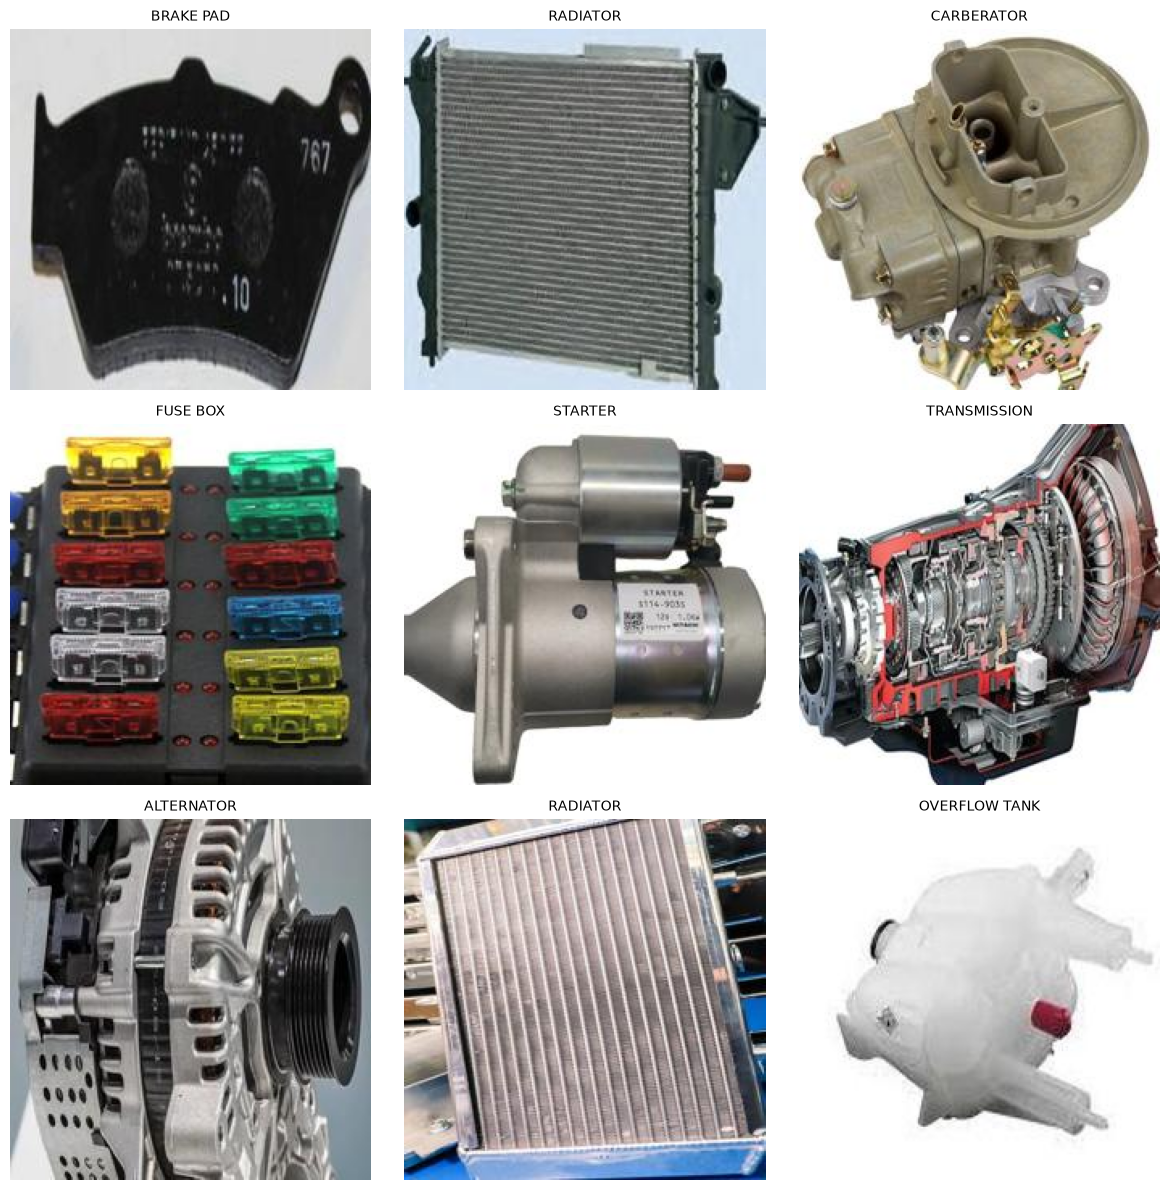

In [5]:
sample_df = df.sample(n=9, random_state=42)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

base_path = "dataset" 

for i, (index, row) in enumerate(sample_df.iterrows()):
    
    img_path = os.path.join(base_path, row['filepaths'])
    
    img = mpimg.imread(img_path)
    
    axes[i].imshow(img)
    axes[i].set_title(row['labels'], fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [6]:
import numpy as np
from data_pipeline import create_dataset_pipeline

train_data = create_dataset_pipeline('dataset/train', augment=True)

for images, labels in train_data.take(1):
    
    print(f"Batch images shape: {images.shape}")
    print(f"Batch labels shape: {labels.shape}")
    
    min_pixel = np.min(images.numpy())
    max_pixel = np.max(images.numpy())
    
    print(f"Pixel range: [{min_pixel:.2f}, {max_pixel:.2f}]")

Found 8739 files belonging to 50 classes.
Batch images shape: (32, 224, 224, 3)
Batch labels shape: (32,)
Pixel range: [0.00, 1.00]
